In [1]:
import pandas as pd

ratings = pd.read_csv('../../data/ml-100k/u.data', sep='\t',
                       names=['user_id', 'item_id', 'rating', 'timestamp'])
users = pd.read_csv('../../data/ml-100k/u.user', sep='|',
                     names=['user_id', 'age', 'gender', 'occupation', 'zip_code'])

user_item_matrix = ratings.pivot_table(index='user_id', columns='item_id', values='rating')

1. Sparce Matrix Handling

In [2]:
user_item_filled = user_item_matrix.fillna(0)

2. Encoding demographic features

In [3]:
users_encoded = pd.get_dummies(users, columns=['gender', 'occupation'], drop_first=True)

users_encoded = users_encoded.drop(columns=['zip_code']).set_index('user_id')

3. Combine ratings + demographic features into one matrix

In [4]:
combined_features = user_item_filled.join(users_encoded)
combined_features.columns = combined_features.columns.astype(str)
print(combined_features.shape)
combined_features.head()

(943, 1704)


,1,2,3,4,5,6,7,8,9,10,...,occupation_marketing,occupation_none,occupation_other,occupation_programmer,occupation_retired,occupation_salesman,occupation_scientist,occupation_student,occupation_technician,occupation_writer
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,False,False,False,False,False,False,False,False,True,False
2,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,False,False,True,False,False,False,False,False,False,False
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
5,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,True,False,False,False,False,False,False,False


4. Scale Everything

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(combined_features)
print(scaled_features.shape)

(943, 1704)


5. Perform PCA to reduce dimensionality

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=241)
reduced_features = pca.fit_transform(scaled_features)
print("Variance explained by 241 components: ", round(sum(pca.explained_variance_ratio_), 2))

Variance explained by 241 components:  0.8


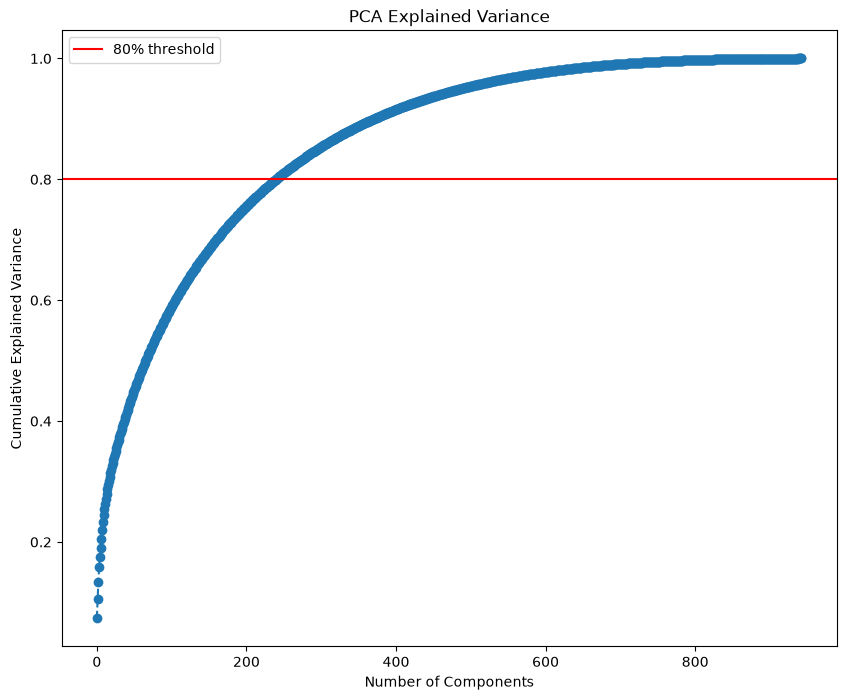

Components needed for 80% variance: 241


In [7]:

#Deletable code snippet
#Reason: was used to determine the number of components needed to explain 80% of the variance, but we have already set n_components=241 which explains more than 80% of the variance.
import numpy as np
import matplotlib.pyplot as plt


pca_full =  PCA().fit(scaled_features)
cumulative_Variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 8))
plt.plot(cumulative_Variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.axhline(y=0.80, color='r', linestyle='-', label = '80% threshold')
plt.legend()
plt.show()

n_components_80 = np.argmax(cumulative_Variance >= 0.80) + 1
print(f"Components needed for 80% variance: {n_components_80}")

Fitting K-Means on the reduced features

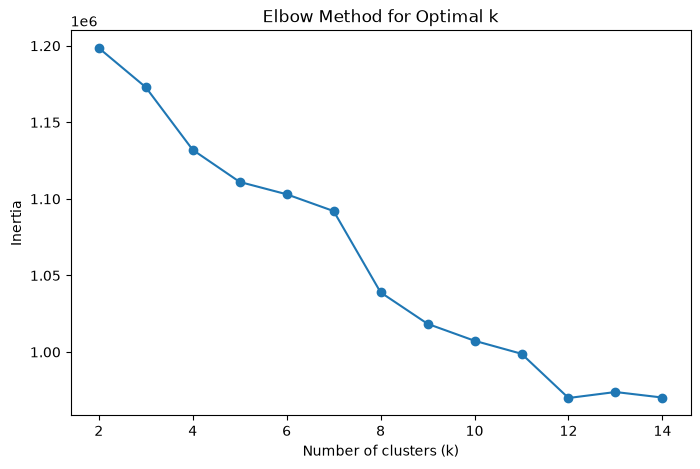

In [8]:
from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(reduced_features)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

Silhoutte Score to find the optimal number of clusters

k=2, silhouette score=0.405
k=3, silhouette score=0.382
k=4, silhouette score=0.213
k=5, silhouette score=0.397
k=6, silhouette score=0.354
k=7, silhouette score=0.201
k=8, silhouette score=0.160
k=9, silhouette score=0.157
k=10, silhouette score=0.165
k=11, silhouette score=0.146
k=12, silhouette score=0.066
k=13, silhouette score=0.144
k=14, silhouette score=0.213


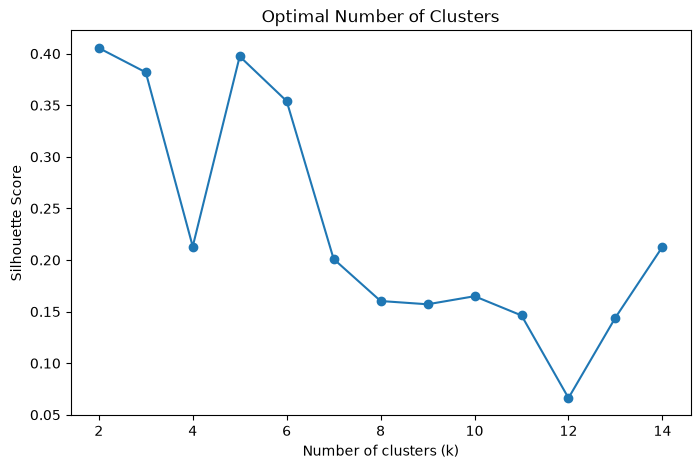

In [9]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(reduced_features)
    score = silhouette_score(reduced_features, labels)
    silhouette_scores.append(score)
    print(f"k={k}, silhouette score={score:.3f}")

plt.figure(figsize=(8,5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Optimal Number of Clusters')
plt.show()

In [10]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(reduced_features)


# Add cluster labels back to your users dataframe for interpretation
users_with_clusters = users.set_index("user_id").copy()
users_with_clusters["cluster"] = cluster_labels


print(users_with_clusters['cluster'].value_counts())
users_with_clusters.groupby('cluster')[['age']].mean().round(1)

cluster
1    750
2    190
0      1
4      1
3      1
Name: count, dtype: int64


,age
cluster,
0,35.0
1,34.4
2,32.8
3,50.0
4,22.0


In [11]:
# Check ratings count per user, and see if it correlates with these outlier clusters
ratings_per_user = ratings.groupby('user_id').size()
users_with_clusters['num_ratings'] = ratings_per_user

print(users_with_clusters.groupby('cluster')['num_ratings'].describe())

         count        mean        std    min     25%    50%     75%    max
cluster                                                                   
0          1.0  254.000000        NaN  254.0  254.00  254.0  254.00  254.0
1        750.0   65.145333  46.580037   20.0   29.00   49.5   92.75  435.0
2        190.0  260.342105  87.227695  139.0  194.25  237.5  305.00  636.0
3          1.0  685.000000        NaN  685.0  685.00  685.0  685.00  685.0
4          1.0  737.000000        NaN  737.0  737.00  737.0  737.00  737.0


Removing the outliers and re-fitting K-Means

In [12]:
# Identify outlier users (extremely high rating counts)
outlier_user_ids = users_with_clusters[users_with_clusters['cluster'].isin([0, 3, 4])].index
print("Outlier users:", outlier_user_ids.tolist())

# Remove them from the feature matrix before re-clustering
combined_features_clean = combined_features.drop(index=outlier_user_ids)
scaled_features_clean = scaler.fit_transform(combined_features_clean)

pca_clean = PCA(n_components=241)
reduced_features_clean = pca_clean.fit_transform(scaled_features_clean)
print("Variance explained:", pca_clean.explained_variance_ratio_.sum())

Outlier users: [339, 405, 655]
Variance explained: 0.7900729976872546


Cleaned DataFrame with cluster labels

k=2, silhouette score=0.400
k=3, silhouette score=0.402
k=4, silhouette score=0.400
k=5, silhouette score=0.170
k=6, silhouette score=0.398
k=7, silhouette score=0.177
k=8, silhouette score=0.225
k=9, silhouette score=0.206


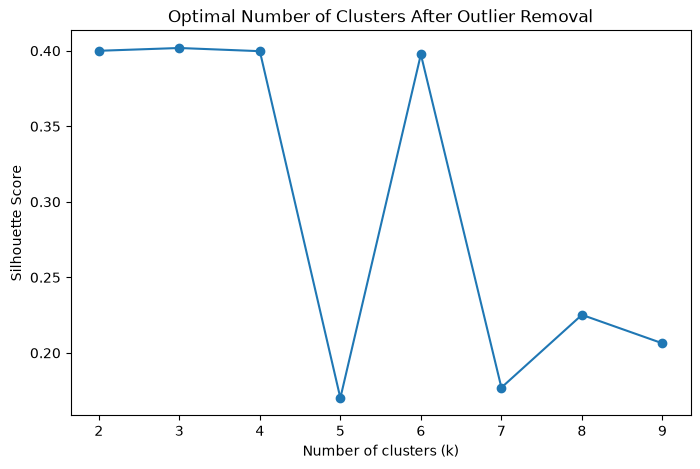

In [13]:
inertias_clean = []
silhouette_scores_clean = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(reduced_features_clean)
    inertias_clean.append(kmeans.inertia_)
    score = silhouette_score(reduced_features_clean, labels)
    silhouette_scores_clean.append(score)
    print(f"k={k}, silhouette score={score:.3f}")

plt.figure(figsize=(8,5))
plt.plot(k_range, silhouette_scores_clean, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Optimal Number of Clusters After Outlier Removal')
plt.show()

Reffiting K-Means on the cleaned data

In [14]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels_clean = kmeans_final.fit_predict(reduced_features_clean)

users_clean = users_with_clusters.drop(index=outlier_user_ids).copy()
users_clean['cluster'] = cluster_labels_clean

print(users_clean['cluster'].value_counts())
print(users_clean.groupby('cluster')[['age', 'num_ratings']].mean())

cluster
0    750
1    189
2      1
Name: count, dtype: int64
               age  num_ratings
cluster                        
0        34.382667    65.021333
1        32.783069   260.984127
2        21.000000   232.000000


Genre preferences vectors

In [15]:
genre_cols = ['unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy',
              'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
              'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

movies = pd.read_csv('../../data/ml-100k/u.item', sep='|', encoding='latin-1',
                      names=['item_id', 'title', 'release_date', 'video_release_date',
                             'IMDb_URL'] + genre_cols)

movies_clean = movies.drop(columns=['release_date', 'video_release_date', 'IMDb_URL'])

In [16]:
# Merge ratings with movie genre flags
ratings_with_genres = ratings.merge(movies_clean, on='item_id')

genre_cols = ['unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy',
              'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
              'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

# For each genre, compute each user's average rating for movies in that genre
genre_profiles = {}
for genre in genre_cols:
    genre_movies = ratings_with_genres[ratings_with_genres[genre] == 1]
    genre_avg = genre_movies.groupby('user_id')['rating'].mean()
    genre_profiles[genre] = genre_avg

genre_profile_df = pd.DataFrame(genre_profiles)
genre_profile_df = genre_profile_df.fillna(0)  # user never rated that genre
print(genre_profile_df.shape)
genre_profile_df.head()

(943, 19)


,unknown,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
user_id,,,,,,,,,,,,,,,,,,,
1,4.0,3.333333,2.928571,3.333333,2.200000,3.472527,3.440000,4.8,3.925234,3.5,5.0,3.461538,2.923077,3.600000,3.931818,4.000000,3.615385,3.680000,3.666667
2,0.0,3.800000,4.333333,4.000000,3.000000,3.812500,3.777778,0.0,3.828571,3.0,4.5,3.000000,3.000000,3.500000,4.125000,3.750000,3.583333,3.666667,0.000000
3,0.0,2.785714,3.500000,0.000000,0.000000,2.583333,3.000000,5.0,2.909091,0.0,2.5,2.400000,2.000000,3.181818,3.400000,2.750000,2.523810,2.800000,0.000000
4,0.0,3.875000,3.500000,0.000000,0.000000,5.000000,4.750000,5.0,4.500000,0.0,0.0,4.000000,5.000000,4.000000,4.333333,3.833333,3.909091,4.500000,0.000000
5,4.0,3.142857,3.242424,3.785714,2.448276,3.000000,3.888889,0.0,2.666667,2.5,5.0,2.535714,3.333333,3.000000,2.315789,3.515152,2.947368,3.214286,2.500000


In [17]:
combined_features_v2 = genre_profile_df.join(users_encoded)
combined_features_v2.columns = combined_features_v2.columns.astype(str)
print(combined_features_v2.shape)  # should be ~943 x 47 (19 genres + ~28 demographic cols)

scaler_v2 = StandardScaler()
scaled_features_v2 = scaler_v2.fit_transform(combined_features_v2)

(943, 41)


sILhouette Score to find the optimal number of clusters after outlier removal

k=2, silhouette score=0.103
k=3, silhouette score=0.058
k=4, silhouette score=0.074
k=5, silhouette score=0.051
k=6, silhouette score=0.086
k=7, silhouette score=0.053
k=8, silhouette score=0.064
k=9, silhouette score=0.081


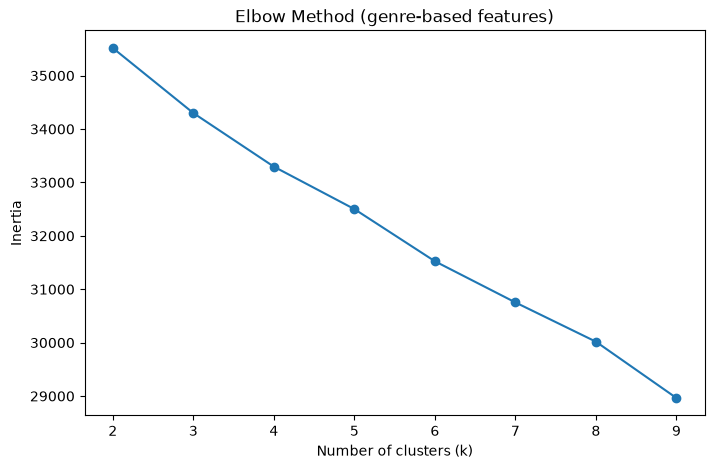

In [18]:
inertias_v2 = []
silhouette_scores_v2 = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features_v2)
    inertias_v2.append(kmeans.inertia_)
    score = silhouette_score(scaled_features_v2, labels)
    silhouette_scores_v2.append(score)
    print(f"k={k}, silhouette score={score:.3f}")

plt.figure(figsize=(8,5))
plt.plot(k_range, inertias_v2, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method (genre-based features)')
plt.show()

Changing the number of clusters to 6 and re-fitting K-Means on the cleaned data

In [19]:
kmeans_final_v2 = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_labels_v2 = kmeans_final_v2.fit_predict(scaled_features_v2)

users_v2 = users.set_index('user_id').copy()
users_v2['cluster'] = cluster_labels_v2

print(users_v2['cluster'].value_counts())
print(users_v2.groupby('cluster')['age'].mean())

cluster
2    421
1    260
4    231
3     12
0     12
5      7
Name: count, dtype: int64
cluster
0    35.666667
1    36.757692
2    32.703088
3    36.750000
4    33.285714
5    32.571429
Name: age, dtype: float64


Profiling the clusters to understand the characteristics of each cluster

In [20]:
# Average genre preference per cluster
cluster_genre_profile = genre_profile_df.copy()
cluster_genre_profile['cluster'] = cluster_labels_v2

print(cluster_genre_profile.groupby('cluster')[genre_cols].mean().round(2))

         unknown  Action  Adventure  Animation  Children's  Comedy  Crime  \
cluster                                                                     
0           0.00    3.50       3.04       1.78        1.98    2.91   3.85   
1           0.02    3.70       3.45       1.42        2.12    3.61   3.82   
2           0.05    3.73       3.76       3.56        3.63    3.63   3.73   
3           0.00    3.55       3.91       2.88        3.26    3.65   3.18   
4           0.04    2.86       2.58       1.85        2.41    2.93   2.86   
5           0.00    3.49       2.83       0.89        2.43    2.93   3.34   

         Documentary  Drama  Fantasy  Film-Noir  Horror  Musical  Mystery  \
cluster                                                                     
0               0.67   3.90     1.50       2.29    2.69     2.12     3.41   
1               0.73   3.91     0.49       1.94    2.33     1.96     3.46   
2               1.96   3.88     2.90       3.26    3.39     3.58     3.77  

1. Saving the trained model using joblib or pickle for future use

In [21]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Save the K-Means model
joblib.dump(kmeans_final_v2, '../models/kmeans_model.pkl')


# Save the scaler used for clustering (needed to transform new user data the same way)
joblib.dump(scaler_v2, '../models/scaler.pkl')

joblib.dump(genre_profile_df, '../models/genre_profile_df.pkl')  # Save the genre profile DataFrame for reference

joblib.dump(list(combined_features_v2.columns), '../models/combined_features_v2.pkl')  # Save the combined features DataFrame for reference

print("K-Means model, scaler, and genre profile saved successfully to '../models/' directory.")

K-Means model, scaler, and genre profile saved successfully to '../models/' directory.
